In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import math

def normalised_gaussian(r, sigma):

    A = 1/ (2 * np.pi * sigma**2)
    value = A * np.exp(- r**2 / (2 * sigma**2))
    return value

def distance(coord1, coord2):
    r_x = (coord1[0] - coord2[0])**2
    r_y = (coord1[1] - coord2[1])**2
    r =  math.sqrt(r_x + r_y)
    return r

# Calculates the vector field at 1 grid point
def calculate_vector_field_one(scan_points, scan_vectors, grid_point):
    
    initilised_vector = [0, 0]

    for i in range(len(scan_points)):

        R = distance(scan_points[i], grid_point)
        val = normalised_gaussian(R, 1)

        vec = [j * val for j in scan_vectors[i]]

        initilised_vector = [x + y for x, y in zip(initilised_vector, vec)]

    return initilised_vector



$$
f(r) = \frac{1}{2 \pi \sigma^2} \exp\left(\frac{r^2}{2\sigma^2}\right)
$$

In [285]:

nx, ny = (3, 3)
x = np.linspace(-2, 2, nx)
y = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x, y)

grid_points = np.column_stack((X.ravel(), Y.ravel()))

scan_points = [[0, 0.5], [0, -0.5], [0.5, 0], [-0.5, 0]]
scan_vectors = [[0, 1], [0, -1], [1, 0], [-1, 0]]

grid_vectors = []
for i in grid_points:
    vector = calculate_vector_field_one(scan_points, scan_vectors, i)
    grid_vectors.append(vector)




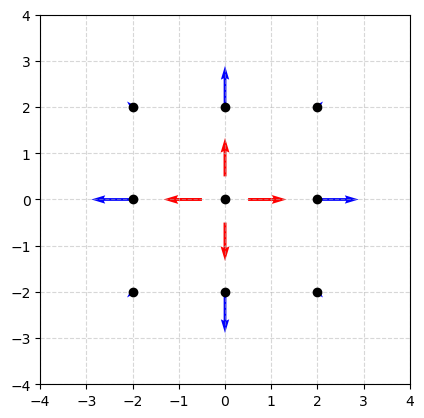

In [286]:

px = grid_points[:, 0]
py = grid_points[:, 1]

vx = [v[0] for v in grid_vectors]
vy = [v[1] for v in grid_vectors]

scan_px = [p[0] for p in scan_points]
scan_py = [p[1] for p in scan_points]

scan_vx = [v[0] for v in scan_vectors]
scan_vy = [v[1] for v in scan_vectors]

fig, ax = plt.subplots()

ax.plot(X, Y, marker='o', color='k', linestyle='none')

ax.quiver(
    px, py,
    vx, vy,
    angles='xy',
    scale_units='xy',
    scale=0.05,
    color='blue'
)

ax.quiver(
    scan_px, scan_py,
    scan_vx, scan_vy,
    angles='xy',
    scale_units='xy',
    scale=1.2,
    color='red',
    width=0.008
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

ax.set_aspect('equal', adjustable='box')

plt.show()